In [ ]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
# Dataset
data = {
'Age': [25, 35, 45, 20, 50, 40, 23, 48, 33, 52],
'Income': [40, 50, 65, 30, 70, 60, 35, 63, 48, 80],
'Buy': ['No', 'No', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes']
}
df = pd.DataFrame(data)
X = df[['Age', 'Income']]
y = df['Buy']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Predictions:", y_pred.tolist())
print("Accuracy:", accuracy_score(y_test, y_pred))


Predictions: ['No', 'Yes', 'Yes']
Accuracy: 0.6666666666666666


   Height_cm  Weight_kg
0        150         45
1        155         50
2        160         52
3        165         56
4        170         60
5        175         65
6        180         70
7        185         75


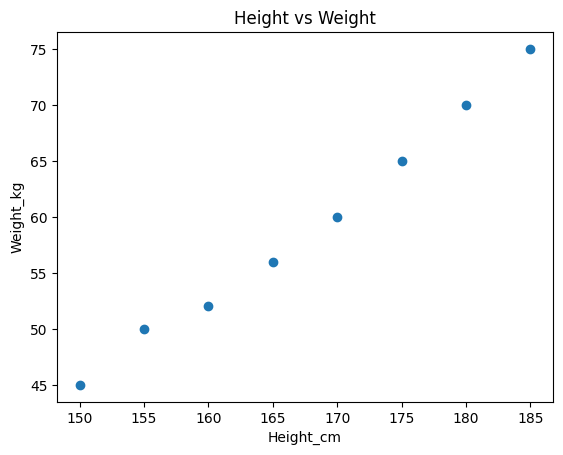

In [ ]:
import matplotlib.pyplot as plt
data = {
    'Height_cm': [150, 155, 160, 165, 170, 175, 180, 185],
    'Weight_kg': [45, 50, 52, 56, 60, 65, 70, 75]
}

df = pd.DataFrame(data)
print(df)

plt.scatter(df["Height_cm"],df["Weight_kg"])
plt.xlabel("Height_cm")
plt.ylabel("Weight_kg")
plt.title("Height vs Weight")
plt.show()


In [ ]:
from scipy.spatial import distance
x = df.loc[0]   # Person 1
y = df.loc[1]   # Person 2

# --- Distance calculations ---
euclidean_dist = distance.euclidean(x, y)
manhattan_dist = distance.cityblock(x, y)
minkowski_dist = distance.minkowski(x, y, p=3)

print("Euclidean distance :", euclidean_dist)
print("Manhattan distance :", manhattan_dist)
print("Minkowski distance (p=3):", minkowski_dist)


Euclidean distance : 7.0710678118654755
Manhattan distance : 10
Minkowski distance (p=3): 6.299605249474365


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
data = {
    'Height_cm': [150, 155, 160, 165, 170, 175, 180, 185],
    'Weight_kg': [45, 50, 52, 56, 60, 65, 70, 75],
    'Calories_Intake': [1800, 1900, 2000, 2100, 2200, 2300, 2500, 2600]
}

df = pd.DataFrame(data)
print(df)

X=df[["Height_cm","Weight_kg"]]
y=df["Calories_Intake"]
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=KNeighborsRegressor(n_neighbors=3)
model.fit(X_train,Y_train)
y_pred=model.predict(X_test)
mse=mean_squared_error(Y_test,y_pred)
print("Mean Squared Error:",mse)
new_point = pd.DataFrame({'Height_cm': [172], 'Weight_kg': [62]})
predicted_calories = model.predict(new_point)

print("Predicted Calories Intake:", predicted_calories[0])



   Height_cm  Weight_kg  Calories_Intake
0        150         45             1800
1        155         50             1900
2        160         52             2000
3        165         56             2100
4        170         60             2200
5        175         65             2300
6        180         70             2500
7        185         75             2600
Mean Squared Error: 2777.777777777788
Predicted Calories Intake: 2266.6666666666665


K =  1 | R² = 0.950 | RMSE = 132.288
K =  2 | R² = 0.940 | RMSE = 145.774
K =  3 | R² = 0.901 | RMSE = 186.339
K =  4 | R² = 0.835 | RMSE = 241.091
K =  5 | R² = 0.733 | RMSE = 306.268
K =  6 | R² = 0.625 | RMSE = 363.242
K =  7 | R² = 0.502 | RMSE = 418.818
K =  8 | R² = 0.364 | RMSE = 473.187
K =  9 | R² = 0.206 | RMSE = 528.713
K = 10 | R² = 0.027 | RMSE = 585.256

Best K value: 1 (R² = 0.950)


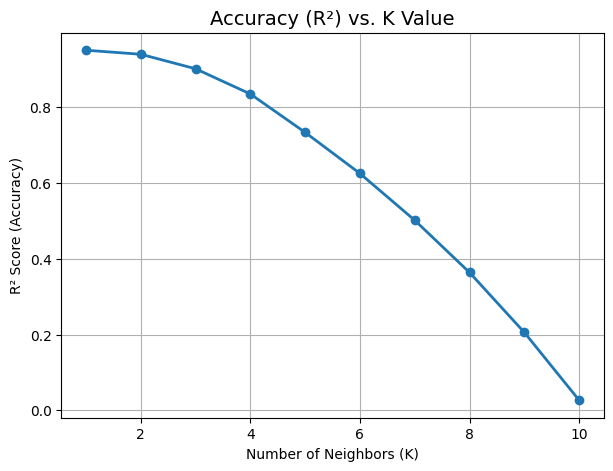

In [ ]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
k_values = np.arange(1, 11)
r2_scores = []
rmse_values = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(Y_test, y_pred)
    mse = mean_squared_error(Y_test, y_pred)
    rmse = np.sqrt(mse)
    r2_scores.append(r2)
    rmse_values.append(rmse)
    print(f"K = {k:2d} | R² = {r2:.3f} | RMSE = {rmse:.3f}")

best_k = k_values[np.argmax(r2_scores)]
print(f"\nBest K value: {best_k} (R² = {max(r2_scores):.3f})")

plt.figure(figsize=(7,5))
plt.plot(k_values, r2_scores, marker='o', linestyle='-', linewidth=2)
plt.title("Accuracy (R²) vs. K Value", fontsize=14)
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("R² Score (Accuracy)")
plt.grid(True)
plt.show()


In [ ]:
import time
model_brute=KNeighborsRegressor(n_neighbors=3,algorithm="brute")
model_brute.fit(X_train,Y_train)
model_kdtree=KNeighborsRegressor(n_neighbors=3,algorithm="kd_tree")
model_kdtree.fit(X_train,Y_train)
start=time.time()
predict_brute=model_brute.predict(X_test)
end = time.time()
duration = end - start
print("Brute time",duration)
start1=time.time()
predict_kdtree=model_kdtree.predict(X_test)
end1= time.time()
duration1 = end1 - start1
print("Kd tree",duration1)


Brute time 0.002790689468383789
Kd tree 0.0023148059844970703
